In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as np
from jax import random
from jax import vmap
from jax.flatten_util import ravel_pytree
from jax import grad
from jax import jit
import seaborn as snb
from time import time

# distributions
from jax.scipy.stats import multivariate_normal as mvn

# exercise 9
from ex9 import eval_density_grid
from ex9 import check_leapfrog_implementation
from ex9 import compute_Rhat, compute_effective_sample_size
from ex9 import plot_predictions


# use 64-bit precision
from jax import config
config.update("jax_enable_x64", True)

# style stuff
snb.set_style('darkgrid')
snb.set_theme(font_scale=1.25)
colors = snb.color_palette()

# 02477 Bayesian Machine Learning - Exercise 9


The purpose of this exercise is to

- investigate and become familiar with the Hamiltonian Monte Carlo (HMC) algorithm and the components involved (i.e. Hamiltonian dynamics, leapfrog integration etc)
- to practice applying HMC for posterior inference in Bayesian models
- to practice computing posterior and predictive distributions using MCMC samples
- become familiar with convergence diagnostics like $\hat{R}$ and effective sample size.

First, we will study the details of HMC and then we will apply the algorithm for inference in two different models: 1) a non-conjugate heteroscedastic regression model and 2) a small neural network.



- Part 1: The Hamiltonian function and Leapfrog integration for univariate Gaussian - use pen & paper
- Part 2: Implementing a leapfrog integrator
- Part 3: Implementing the HMC algorithm
- Part 4: HMC for heteroscedastic regression model
- Part 5: HMC for a small Bayesian neural network


**Note**: The exercise contains several **discussion questions**, which are questions, where you are supposed to actively experiment with the code and/or reason with the equations to arrive at the relevant conclusions. This also means that we won't provide a specific solution for this task. However, you are more than welcome to check your understanding and your conclusions with the TAs. Instead of proving the full description for every discussion question, we simply tag it with: [**Discussion question**] after the question.



# Re-cap of HMC Theory

**Hamiltonian Monte Carlo** (HMC) is the state-of-the-art MCMC algorithm designed to produce samples from a given target probability density of interest $p_t(\boldsymbol{\theta})$ for $\boldsymbol{\theta} \in \mathbb{R}^D$.

Using **Hamiltonian Dynamics**, HMC can often explore target distributions much more efficiently than algorithms like Metropolis Random Walk (MRW). HMC augments the target distribution with a **momentum** parameter $\boldsymbol{\nu} \in \mathbb{R}^D$ as follows:
$$p(\boldsymbol{\theta}, \boldsymbol{\nu})=p_t(\boldsymbol{\theta})p(\boldsymbol{\nu})\tag{Augmented target distribution},$$

where we often refer to $(\boldsymbol{\theta}, \boldsymbol{\nu})$ as **phase-space**. We interpret the variables $(\boldsymbol{\theta}, \boldsymbol{\nu})$ as representing the position and momentum, respectively, of a particle. We define the energies of the system as follows:
$$
\begin{align*}
E(\boldsymbol{\theta}) &= -\log p_t(\boldsymbol{\theta}),\tag{Potential energy}\\
K(\boldsymbol{\nu}) &= -\log p(\boldsymbol{\nu}), \tag{Kinetic energy}\\
H(\boldsymbol{\theta}, \boldsymbol{\nu}) &= E(\boldsymbol{\theta}) + K(\boldsymbol{\nu}),\tag{Hamiltonian function}
\end{align*}
$$
where all three quantities $E, K,$ and $H$ are defined up to additive constants.

The proposal mechanism of HMC uses a **leapfrog integrator** to compute the trajectory of the state $(\boldsymbol{\theta}, \boldsymbol{\nu})$ in phase-space by solving **Hamilton's equations**, where the $j$'th step of the leapfrog integrator is given by:
$$
\begin{align*}
    \bm{\nu}_{j+1/2} &= \bm{\nu}_j - \frac{\eta}{2} \nabla_{\bm{\theta}}E(\bm{\theta}_j)\\
    \bm{\theta}_{j+1} &=\bm{\theta}_j + \eta \bm{\nu}_{j+1/2}\\
    \bm{\nu}_{j+1} &= \bm{\nu}_{j+1/2} - \frac{\eta}{2}\nabla_{\bm{\theta}} E(\bm{\theta}_{j+1})
\end{align*}
$$
for $j = 0, 1, \dots, L-1$, where $L$ is the number of leapfrogs steps and $\eta > 0$ is the step-size. Suppose we run the leapfrog integrator for $L$ starting from $(\boldsymbol{\theta}_{k-1}, \boldsymbol{\nu}_{k-1})$, we denote the result as

$$(\boldsymbol{\theta}^*, \boldsymbol{\nu}^*) = \text{leapfrog}_{\eta, L}(\boldsymbol{\theta}_{k-1}, \boldsymbol{\nu}_{k-1}).$$

Exact Hamiltonian dynamics will conserve the value of the Hamiltonian function, i.e. $H(\boldsymbol{\theta}_{k-1}, \boldsymbol{\nu}_{k-1}) = H(\boldsymbol{\theta}^*, \boldsymbol{\nu}^*)$, but because of the discretization error introduced by the numerical integrator, the Hamiltonian will only be approximately conserved, i.e. $H(\boldsymbol{\theta}_{k-1}, \boldsymbol{\nu}_{k-1}) \approx H(\boldsymbol{\theta}^*, \boldsymbol{\nu}^*)$ depending on the step-size $\eta$.


### The Hamiltonian Monte Carlo Algorithm

We can now summarize the HMC algorithm as follows.

For $k = 1, 2, \dots, S$, do
- Sample new momentum variable $\boldsymbol{\nu}_{k-1} \sim \mathcal{N}(\boldsymbol{0}, \boldsymbol{I})$

- Use leapfrog integration to compute $\left(\boldsymbol{\theta}^*, \boldsymbol{\nu}^*\right) = \text{leapfrog}_{\eta, L}\left(\boldsymbol{\theta}_{k-1}, \boldsymbol{\nu}_{k-1}\right)$

- Compute acceptance probability $a_k = \min\left(1, \exp\left[-H(\boldsymbol{\theta}^*, \boldsymbol{\nu}^*) + H(\boldsymbol{\theta}_{k-1}, \boldsymbol{\nu}_{k-1})\right]\right)$

- Set $\boldsymbol{\theta}_k= \boldsymbol{\theta}^*$ with probability $a_k$, otherwise $\boldsymbol{\theta}_k = \boldsymbol{\theta}_{k-1},$

where $S$ is the number of iterations.

Note that mature implementations of HMC (e.g. in Stan, Blackjax, Tensorflow etc) typically uses step-size adaption and the NUTS (No U-turn sampler) variant to deal with $\eta$ and $L$ dynamically. However, in this exercise, our goal is to build a simple implementation of HMC using fixed value for $\eta$ and $L$.

# Re-cap of convergence diagnostics theory
Besides HMC, we will also study the MCMC convergence diagnostics denoted $\hat{R}$ as well as the effective sample size $S_\text{eff}$.  MCMC theory states that a well-designed MCMC algorithm converges asymptotically to the true target distribution, meaning that the Markov chain eventually will converge to the target distribution. The downside is that there is no strict theory for predicting when a chain will reach its stationary distribution in general, but there do exist heuristics that work very well in practice.


**Assessing convergence**

Intuitively, we can test convergence by running **multiple chains** in parallel starting from **different initial conditions**. After a given number of iterations, we can compare the chains. If the chains have reached stationarity, then they should all have the same stationary distribution independent of the initial condition. Therefore, if our chains do not have the same distributions, we can conclude the chains have not reached stationarity yet. In this case, we say that the chains have not **mixed**.

In practice, the so-called $\hat{R}$-statistic, also called the **potential scale reduction factor**, works well for assessing convergence:

$$\begin{align*}
\hat{R}^2 = \frac{S-1}{S} + \frac{1}{S}\frac{B}{W} \tag{1},
\end{align*}$$

where $S$ is the number of samples/iterations, $B$ is the **between-chain variance** and $W$ is the **within-chain variance**. If the between-chain variance is equal to the within-chain variance, then $\hat{R} = 1$, otherwise $\hat{R} > 1$. For most applications, the threshold $\hat{R} < 1.1$ works well for assessing convergence, but for more critical applications the threshold $\hat{R} < 1.01$ is recommended.

For more details, see Section 12.6.2.2. in Murphy2 or see p. 284 in Bayesian Data Analysis (http://www.stat.columbia.edu/~gelman/book/BDA3.pdf).

**Effective sample size**

Another very useful statistic in MCMC is the so-called **effective sample size (ESS)** defined by

$$\begin{align}
S_{\text{eff}}  = \frac{S}{\sum_{t=-\infty}^{\infty} \rho_t} = \frac{S}{1 + 2\sum_{t=1}^\infty \rho_t}\tag{2},
\end{align}$$


where $\rho_t$ is the autocorrelation of the chains at time lag $t$. Informally, a set of $S$ MCMC samples contains less information than $S$ independent samples from the same distribution due to the correlation between MCMC samples. The effective sample size helps us correct for this when computing the MCSE.

The provided functions `compute_Rhat` and `compute_effective_sample_size` compute $\hat{R}$ and $S_{\text{eff}}$, respectively. 

These diagnostics are evaluated after removing the **warmup** samples. And after we computed the diagnostics, we **merge** the samples from the individual chains into one long chain before using the samples for inference purposes.


## Part 1:  The Hamiltonian function and Leapfrog integration for univariate Gaussian - use pen & paper


First, we consider a simple toy set-up, where the target distribution $p_t(\theta)$ for $\theta \in \mathbb{R}$ is a univariate Gaussian with mean $m = 1$ and variance $v = \frac12$, i.e. $p_t(\theta) = \mathcal{N}(\theta|m, v)$. Assume the distribution of the momentum $\nu \in \mathbb{R}$ for HMC is also a standardized Gaussian, i.e. $p(\nu) = \mathcal{N}(\nu|0, 1)$.

**Task 1.1**: What is the dimensionality of the state-space (or sampling space) for HMC?

**Solution**

HMC samples the augmented distribution $p(\theta, \nu) = p_t(\theta)p(\nu)$, so the dimensionality of the state-space is $2$.

**End of solution**

Assume $(\theta_0, \nu_0) = (-1, 1)$. 

**Task 1.2**: Evaluate the kinetic energy, potential energy, and the Hamiltonian function for the state $\left(\boldsymbol{\theta}_0, \boldsymbol{\nu}_0\right)$

**Solution**

The kinetic energy is given by:
$$K(\nu_0)= -\log p(\nu_0) = -\log \mathcal{N}(\nu_0|0, 1) = \frac12 \log (2\pi) + \frac12 \approx 1.42$$

The potential energy is given by
$$E(\theta_0) = -\log p_t(\theta_0) = -\log \mathcal{N}\left(\theta_0|1, \frac12\right) = \frac12\log \left(\pi\right) + \frac{1}{2 \frac12}(-1-1)^2 \approx 4.57$$

Finally, the Hamiltonian is given by the sum of the two:
$$H(\theta_0, \nu_0) = E(\theta_0) + K(\nu_0) \approx 5.99$$

**End of solution**

**Task 1.3**: Compute $(\theta_1, \nu_1)$ using the equations for leapfrog integration with step-size $\eta = 0.1$.

**Solution**

The gradient of the potential energy is:
$$\nabla_{\theta}E(\theta) = -\nabla_{\theta} \log p_t(\theta) = \nabla_{\theta} (\theta-1)^2 = 2(\theta -1)$$


and therefore, 
$$\frac{\eta}{2} \nabla_{\bm{\theta}}E(\bm{\theta}) = \frac{1/10}{2} 2\left(\theta -1\right)=\frac{1}{10}\left(\theta -1\right)$$

Using the leapfrog equations:
\begin{align*}
    \bm{\nu}_{1/2} &= \bm{\nu}_0 - \frac{\eta}{2} \nabla_{\bm{\theta}}E(\bm{\theta}_0) = 1 - \frac{1}{10} \left(-1-1\right)=\frac{12}{10}=1.2\\
    \bm{\theta}_{1} &=\bm{\theta}_0 + \eta \bm{\nu}_{1/2} = -1 + \frac{1}{10} \frac{12}{10}=-\frac{88}{100}=-0.88\\
    \bm{\nu}_{1} &= \bm{\nu}_{1/2} - \frac{\eta}{2}\nabla_{\bm{\theta}} E(\bm{\theta}_{1}) = \frac{12}{10}-\frac{1}{10}\left(-\frac{88}{100} -1\right)=\frac{1388}{1000} \approx 1.39
\end{align*}

Hence, the state is $\left(\theta_1, \nu_1\right) \approx \left(-0.88, 1.39\right)$.


**End of solution**


**Task 1.4**: Evaluate the value of the Hamiltonian for $(\theta_1, \nu_1)$ and determine the acceptance probability for $(\theta_1, \nu_1)$ given $(\theta_0, \nu_0)$.

**Solution**

The Hamiltonian for the new state is
$$H(\theta_1, \nu_1) = E(\theta_1) + K(\nu_1) = \frac12 \log(\pi ) + \left(-\frac{88}{100}-1\right)^2 + \frac12 \log (2\pi) + \frac12 \left(\frac{1388}{1000}\right)^2\approx 5.99$$

The acceptance probability is therefore
$$a_k = \min \left( 1, e^{-H(\theta_1, \nu_1) + H(\theta_0, \nu_0)}\right) \approx \min(1, 1.002) = 1.$$

**End of solution**


## Part 2:  Implementing a leapfrog integrator

Next, we will implement a function for leapfrog integration in JaX. We will test the function on using a target distribution for easy validation. Specifically, for $\boldsymbol{\theta} \in \mathbb{R}^2$:

$$p_t(\boldsymbol{\theta}) = \mathcal{N}\left(\boldsymbol{\theta}|\mathbf{0}, \boldsymbol{\Sigma}\right),$$
where $\boldsymbol{\Sigma} = \begin{bmatrix}1 & -0.7\\ -0.7 & 1\end{bmatrix}$.

Let's plot the distribution along with an initial state 

$$\boldsymbol{\theta}_0 = \begin{bmatrix} 1 \\ 1 \end{bmatrix}, \quad\quad \boldsymbol{\nu}_0 = \begin{bmatrix} 1 \\ -1 \end{bmatrix}$$

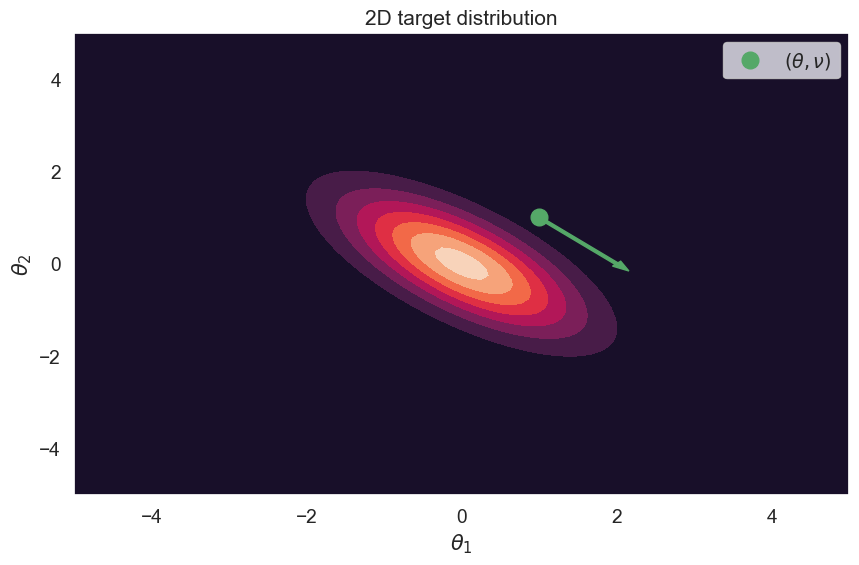

In [3]:
# define 2D target distribution for theta 
Sigma = jnp.array([[1, -0.7], [-0.7, 1]])
log_target_2d = lambda x: jnp.array(mvn.logpdf(x, jnp.zeros(2), Sigma))

# Evaluate target on grid
theta_grid, log_target_grid = eval_density_grid(log_target_2d) 

# define initial state
theta0 = jnp.array([[1.0, 1.]])     # shape: 1x2
nu0 = jnp.array([[1.0, -1.0]])      # shape: 1x2

# plot
def plot_2d_target(ax):
    """ plot contours of log target """
    ax.contourf(theta_grid, theta_grid, jnp.exp(log_target_grid.T))
    ax.set(xlabel='$\\theta_1$', ylabel='$\\theta_2$', title='2D target distribution')

def plot_state(ax, theta, nu, color='g', label=None):
    """ plots state (theta, nu) """
    ax.plot(theta[0,0], theta[0,1], 'o', color=color, label=f'$(\\theta, \\nu)$' if label is None  else label, markersize=12)
    ax.arrow(theta[0,0], theta[0,1], nu[0,0], nu[0,1], width=0.05, color=color)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
plot_2d_target(ax)
plot_state(ax, theta0, nu0)
ax.legend()

In the plot above, the dot shows the position $\boldsymbol{\theta}$ and the arrow shows the momentum $\boldsymbol{\nu}$.

We will now implement some helper functions for evaluating the energy function and the gradient of the potential energy:

In [4]:
########################################################################################
# Energy functions
########################################################################################
def build_energy_functions(log_target):
    """ Helper function for constructing the relevant energy functions and gradients for HMC based on the given log_target function.
        The function log_target must accept JaX arrays of shape NxD, where D is the dimension of the parameter space and N
        is the number of points to be evaluated.
    """

    def kinetic_energy(nu):
        """ evaluates kinetic energy for momentum nu (shape: NxD), returns (N) array of kinetic energies"""
        N, D = nu.shape
        const = 0.5*D*jnp.log(2*jnp.pi) # can be left out
        return const + 0.5*jnp.sum(nu**2, 1).squeeze()
    
    def potential_energy(theta):
        """ evaluates potential energy for position theta (shape: NxD), returns (N) array of potential energies """
        return -log_target(theta).squeeze()
    
    def hamiltonian(theta, nu):
        """ evaluates Hamiltonian for state (theta, nu), returns (N) array of Hamiltonian values """
        return potential_energy(theta) + kinetic_energy(nu)
    
    return hamiltonian, potential_energy, kinetic_energy, grad(potential_energy)

# set up energy functions and gradient
hamiltonian, potential_energy, kinetic_energy, grad_potential_energy = build_energy_functions(log_target_2d)

# test the energy functions for 2d target
print(f'Hamiltonian H(theta0, nu0) = {hamiltonian(theta0, nu0):.3f}')
print(f'Potential energy E(theta0) = {potential_energy(theta0):.3f}')
print(f'Kinetic energy K(nu0) = {kinetic_energy(nu0):.3f}')
print(f'Gradient of potential energy ∇E(θ) = {grad_potential_energy(theta0).squeeze()}')


Hamiltonian H(theta0, nu0) = 7.672
Potential energy E(theta0) = 4.835
Kinetic energy K(nu0) = 2.838
Gradient of potential energy ∇E(θ) = [3.33333333 3.33333333]


Below you are given a template for a `leapfrog` integration function.

**Task 2.1**: Complete the implementation of the leapfrog function given below

*Hints*

- *If the leapfrog integrator is implemented correctly, the value of the Hamiltonian should be approximately constant.*

In [5]:
def leapfrog(theta0, nu0, grad_pot_energy_fun, num_steps, step_size, full_trajectory=True):
    """ computes hamiltonian dynamics using leapfrog integration for D-dimensional problem

        Arguments:
        theta0                  --      Initial position, shape 1xD
        nu0                     --      Initial momentum, shape 1xD
        grad_pot_energy_fun     --      Function for evaluating the gradient of the potential energy, must be compatible with theta0
        num_steps               --      Number of leapfrog steps
        step_size               --      Step-size for integration, positive scalar
        full_trajectory         --      Flag indicating whether the function should return the full trajectory or only the last state.

        Returns:
        theta                   --      Final position after num_steps leapfrog steps
        nu                      --      Final momentum after num_steps leapfrog steps
        theta_trajectory        --      Array of position values for each step (shape: (num_steps+1) x D) if full_trajectory is True
        nu_trajectory           --      Array of momentum values for each step (shape: (num_steps+1) x D) if full_trajectory is True
    """

    if full_trajectory:
        theta_trajectory = [theta0]
        nus_trajectory = [nu0]

    ##############################################################
    # Your solution goes here
    ##############################################################
    
    theta, nu = theta0, nu0
    for k in range(num_steps):
        nu = nu - 0.5*step_size*grad_pot_energy_fun(theta)
        theta = theta + step_size*nu
        nu = nu - 0.5*step_size*grad_pot_energy_fun(theta)

        if full_trajectory:
            theta_trajectory.append(theta)
            nus_trajectory.append(nu)
    
    ##############################################################
    # End of solution
    ##############################################################

    if full_trajectory:
        return theta, nu, jnp.vstack(theta_trajectory), jnp.vstack(nus_trajectory)
    else:
        return theta, nu

# configuration
step_size = 1e-1
num_leapfrog_steps = 5

# define initial state
theta0 = jnp.array([[1.0, 1.]])     # shape: 1x2
nu0 = jnp.array([[1.0, -1.0]])      # shape: 1x2

# set-up energy functions
hamiltonian, potential_energy, kinetic_energy, grad_pot_energy_fun = build_energy_functions(log_target=log_target_2d)

# simulate Hamiltonian dynamic using leapfrog integrator
theta, nu, theta_trajectory, nu_trajectory = leapfrog(theta0, nu0, 
                                  grad_pot_energy_fun, 
                                  num_steps=num_leapfrog_steps, 
                                  step_size=step_size)

# sanity check of leapfrog implementation
check_leapfrog_implementation(theta0, nu0, theta, nu, theta_trajectory, nu_trajectory, hamiltonian, num_leapfrog_steps)

Dimensions of theta and nu: OK.
Shapes of trajectories: OK.
Conservation of Hamiltonian: OK
Sanity check of leapfrog implementation: OK


If everything is implemented correctly, the cell below should plot the trajectory of the position $\theta_k$ for $k = 0, 1, \dots, L$ as well as the energies.

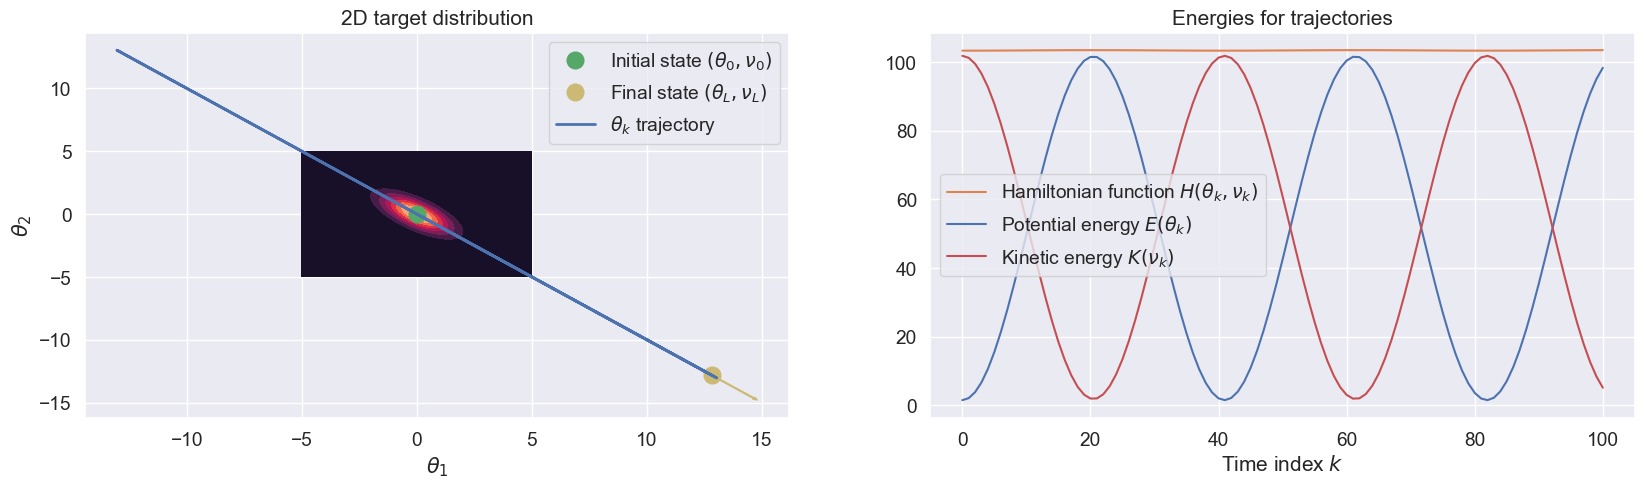

In [6]:
# configuration
step_size = 0.1
num_leapfrog_steps = 100

# define initial state
theta0 = jnp.array([[0., 0.]])     # shape: 1x2
nu0 = jnp.array([[10.0, -10.0]])      # shape: 1x2

# simulate Hamiltonian dynamic using leapfrog integrator
theta, nu, theta_trajectory, nu_trajectory = leapfrog(theta0, nu0, 
                                  grad_pot_energy_fun, 
                                  num_steps=num_leapfrog_steps, 
                                  step_size=step_size)

# evaluate hamiltonian
hamiltonian_trajectory = hamiltonian(theta_trajectory, nu_trajectory)
potential_energies = potential_energy(theta_trajectory)
kinetic_energies = kinetic_energy(nu_trajectory)

# plot target distribution, trajectory and energies
fig, ax = plt.subplots(1, 2, figsize=(20, 5))
plot_2d_target(ax[0])
plot_state(ax[0], theta0, nu0, label=f'Initial state $(\\theta_0, \\nu_0)$')
plot_state(ax[0], theta, nu, color='y', label=f'Final state $(\\theta_L, \\nu_L)$')
ax[0].plot(theta_trajectory[:, 0], theta_trajectory[:, 1], label='$\\theta_k$ trajectory', linewidth=2, color=colors[0])
ax[1].plot(hamiltonian_trajectory, label='Hamiltonian function $H(\\theta_k, \\nu_k)$', color=colors[1])
ax[1].plot(potential_energies, label='Potential energy $E(\\theta_k)$', color=colors[0])
ax[1].plot(kinetic_energies, label='Kinetic energy $K(\\nu_k)$', color=colors[3])
ax[1].set(xlabel='Time index $k$', title='Energies for trajectories')
ax[0].legend()
ax[1].legend();

The value of Hamiltonian is closely connected to the acceptance probability of the HMC algorithm.

**Task 2.2**: Inspect the plots above and determine the approximate acceptance probability for accepting the last state of the trajectory $(\theta_L, \nu_L)$ given the first state of the trajectory $(\theta_0, \nu_0)$

**Solution**

Inspecting the rightmost plot above, we see that the Hamiltonian for the first and last state is approximately the same, and therefore the acceptance probability will approximately be $a_k \approx 1$.

**End of solution**


**Task 2.3**: Play around with the step-size, number of leapfrog steps, and initial state. When does the acceptance probability start to decrease?  [**Discussion question**]


**Task 2.4**: (optional) Set the number of leapfrog steps $L = 100$, the step-size $\eta = 0.1$. Use the template below to verify visually that your implementation satisfies the **reversibility criteria**.

*Hints*:
- *What is supposed to happen if you 1) you run the leapfrog integrator from $(\theta_0, \nu_0)$ to get $(\theta^*, \nu^*)$, 2) flip the sign of the momentum $\nu^*$, 3) run the leapfrog integrator again and 4) flip the momentum again?*

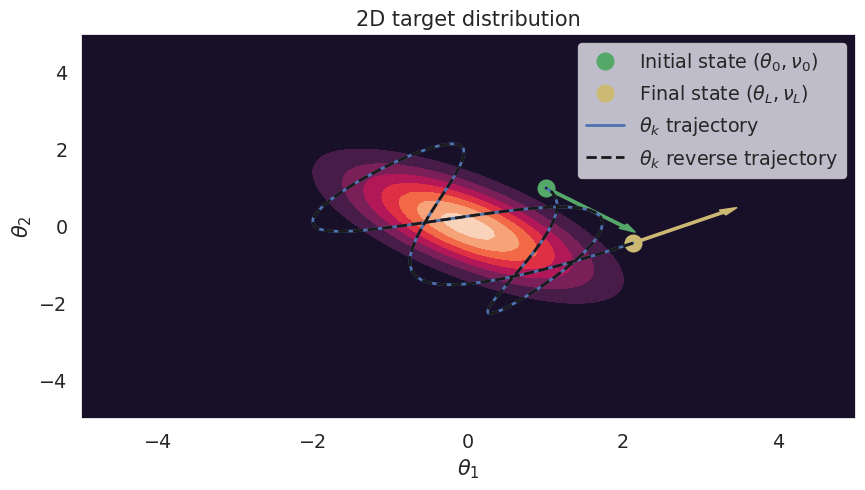

In [6]:
# configuration
step_size = 1e-1
num_leapfrog_steps = 100

# define initial state
theta0 = jnp.array([[1.0, 1.]])     # shape: 1x2
nu0 = jnp.array([[1.0, -1.0]])      # shape: 1x2

# simulate Hamiltonian dynamic using leapfrog integrator
theta, nu, theta_trajectory, nu_trajectory = leapfrog(theta0, nu0, grad_pot_energy_fun, num_leapfrog_steps, step_size)

# simulate reverse trajectory
theta2, nu2, theta_trajectory2, nu_trajectory2 = leapfrog(theta, -nu, grad_pot_energy_fun, num_leapfrog_steps, step_size) # <solution>theta2, nu2, theta_trajectory2, nu_trajectory2 = your implementation goes here.. <eos> 

# plot
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
plot_2d_target(ax)
plot_state(ax, theta0, nu0, label=f'Initial state $(\\theta_0, \\nu_0)$')
plot_state(ax, theta, nu, color='y', label=f'Final state $(\\theta_L, \\nu_L)$')
ax.plot(theta_trajectory[:, 0], theta_trajectory[:, 1], label='$\\theta_k$ trajectory', linewidth=2, color=colors[0])
ax.plot(theta_trajectory2[:, 0], theta_trajectory2[:, 1], label='$\\theta_k$ reverse trajectory', linewidth=2, color='k', linestyle='--')
ax.legend()

## Part 3:  Implementing the HMC algorithm


We are ready to turn our implementation into a complete MCMC algorithm. We have already done the hard work, now it is just a matter of putting the pieces together.

**Task 3.1**: Complete the implementation of the `HMC` function below. 

In [7]:
def HMC(log_target, num_iterations, theta0, num_leapfrog_steps=10, step_size=1e-1, seed=0):
    """ Implements the basic HMC algorithm for D-dimensional target distribution specified by log_target
    
    Arguments:
    log_target          -- Function implementing the logarithm of the target distribution (up to an additive constant). The function must return scalar values and be compatible with theta0
    num_iterations      -- Number of iterations
    theta0              -- Initial position, JaX array of shape 1xD, where D is the dimension
    num_leapfrog_steps  -- Number of leapfrog steps
    step_size           -- Step-size eta for leapfrog integration
    seed                -- seed

    Returns:
    thetas              -- MCMC samples, JaX array of shape (num_iterations+1, D)
    """

    hamiltonian, potential_energy, kinetic_energy, grad_pot_energy_fun = build_energy_functions(log_target)
    key = random.PRNGKey(seed)

    param_shape = theta0.shape
    theta = theta0
    thetas = [theta0]   # list of MCMC samples
    accept_count = 0    # for counting number of accepted samples
    t0 = time()

    # use just-in-time (jit) compilation to speed up computations - comment out if debugging becomes tricky
    hamiltonian = jit(hamiltonian)
    grad_pot_energy_fun = jit(grad_pot_energy_fun)

    for itt in range(num_iterations):

        ###########################################################
        # Your solution goes here
        ###########################################################
        
        # update keys
        key, key_momentum, key_accept = random.split(key, 3)

        # resample momentum
        nu = random.normal(key_momentum, shape=param_shape)

        # propose
        theta_star, nu_star = leapfrog(theta, nu, grad_pot_energy_fun, num_leapfrog_steps, step_size, full_trajectory=False)

        # Compute log acceptance probability
        log_accept_prob = -hamiltonian(theta_star, nu_star) + hamiltonian(theta, nu)
    
        # accept/reject
        u = random.uniform(key_accept)
        if jnp.log(u) < log_accept_prob:
            theta = theta_star
            accept_count = accept_count + 1
 
        thetas.append(theta)

        # verbose
        if (itt+1) % int(num_iterations/10) == 0:
            print(f'Itt {itt+1:5d}/{num_iterations} ({100*(itt+1)/num_iterations:6.2f}%), accept_rate={accept_count/(itt+1):.3f}, time={time()-t0:3.2f}s')
        
        ###########################################################
        # End of solution
        ###########################################################

    print(f'HMC done in {time()-t0:.3f}s with an avg. accept rate={accept_count/num_iterations:.3f}\n\n')

    return jnp.vstack(thetas)

num_leapfrog_steps = 30
num_iterations = 500
step_size = 0.5

theta0 = jnp.array([[0., 0.]])
thetas = HMC(log_target_2d, num_iterations, theta0, num_leapfrog_steps, step_size, seed=123)


 # print summaries
print(f'Estimated mean vector:\n', np.array2string(jnp.mean(thetas, 0), precision=2), '\n')
print(f'Estimated covariance matrix:\n', np.array2string(jnp.cov(thetas.T), precision=2))


Itt    50/500 ( 10.00%), accept_rate=0.980, time=0.54s
Itt   100/500 ( 20.00%), accept_rate=0.990, time=0.64s
Itt   150/500 ( 30.00%), accept_rate=0.987, time=0.75s
Itt   200/500 ( 40.00%), accept_rate=0.990, time=0.86s
Itt   250/500 ( 50.00%), accept_rate=0.992, time=0.97s
Itt   300/500 ( 60.00%), accept_rate=0.993, time=1.07s
Itt   350/500 ( 70.00%), accept_rate=0.991, time=1.18s
Itt   400/500 ( 80.00%), accept_rate=0.990, time=1.29s
Itt   450/500 ( 90.00%), accept_rate=0.991, time=1.40s
Itt   500/500 (100.00%), accept_rate=0.990, time=1.51s
HMC done in 1.511s with an avg. accept rate=0.990


Estimated mean vector:
 [ 0.05 -0.05] 

Estimated covariance matrix:
 [[ 0.94 -0.68]
 [-0.68  0.92]]


How well does the estimated mean and covariance resemble the true moments of the target distribution? What accuracy would you expect if you were estimating the mean and covariance using i.i.d. samples from the true target distribution?


Let's visualize the results.

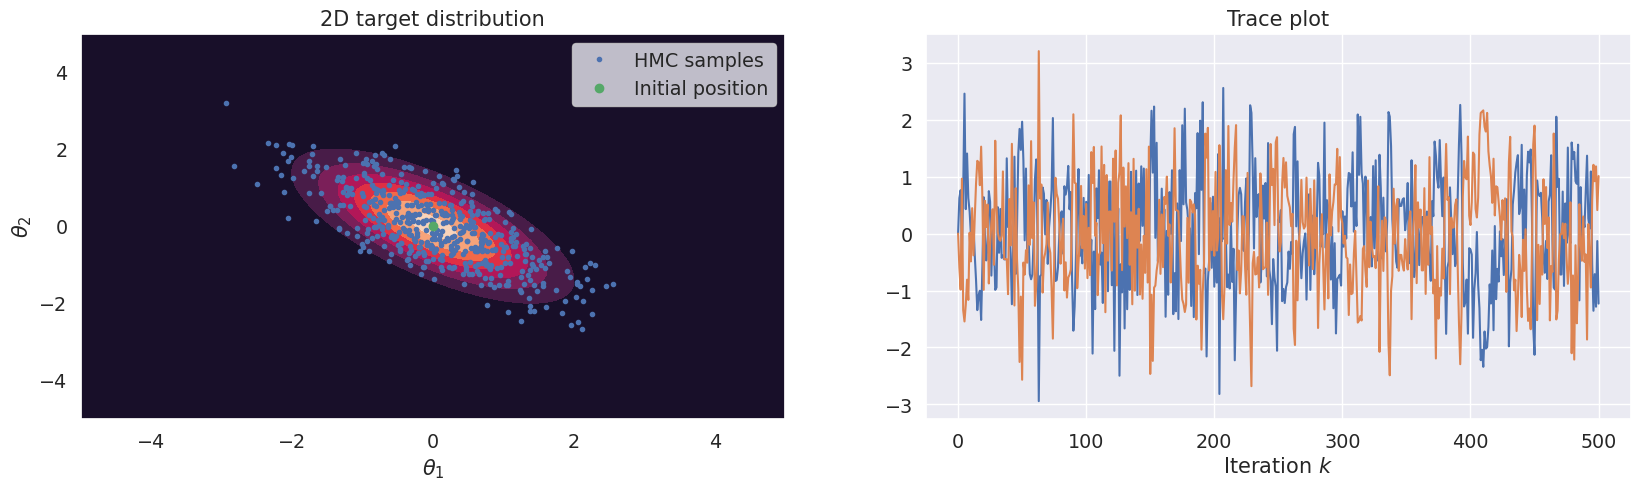

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(20, 5))
plot_2d_target(ax[0])
ax[0].plot(thetas[:, 0], thetas[:, 1], 'b.', label='HMC samples');
ax[0].plot(theta0[0,0], theta0[0, 1], 'go', label='Initial position')
ax[0].legend();
ax[1].plot(thetas);
ax[1].set(xlabel='Iteration $k$', title='Trace plot');

## Part 4:  HMC for heteroscedastic regression model

We are now ready to apply the HMC algorithm to do inference for a regression problem: the goal is to **predict the tip** based on the **total restaurant bill** (see [link](https://rdrr.io/cran/reshape2/man/tips.html) for more details about the data). Let's load the data via seaborn and plot it:

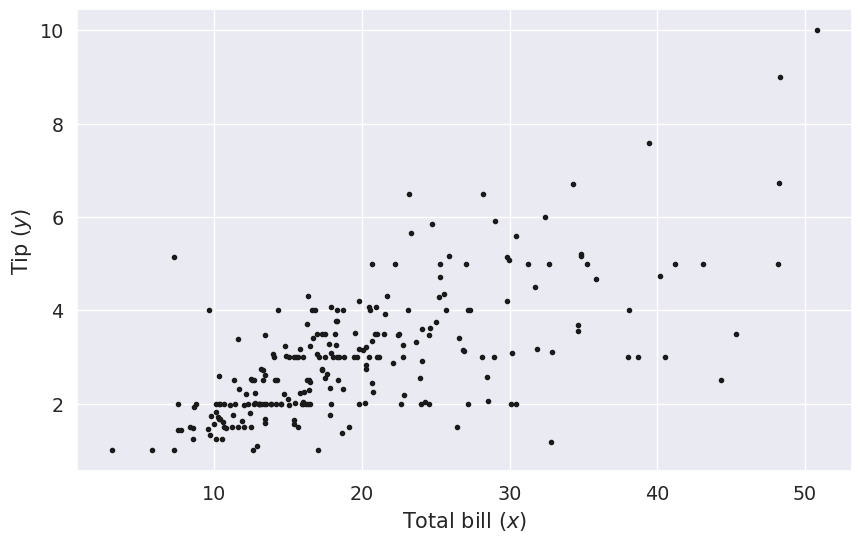

In [9]:
# load restaurant tip data via seaborn
df = snb.load_dataset('tips')
sort = jnp.argsort(df['total_bill'].values)

# extract inputs x and output y
bill = df['total_bill'].values[sort]
tip  = df['tip'].values[sort]       
x_train = jnp.array(bill)[:, None] # shape (N, 1)
y_train = jnp.array(tip)[:, None]  # shape (N, 1)



# plot data
def plot_data(ax):
    ax.plot(x_train, y_train, 'k.')
    ax.set(xlabel='Total bill $(x)$', ylabel='Tip $(y)$')

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
plot_data(ax)

Consider the following model for the tip $(y_n)$ as a function of the total bill $(x_n)$:
$$y_n = f(x_n) + \epsilon_n = w_0 + w_1 x_n + \epsilon_n,$$
where $\epsilon_n$ is additive noise and $f(x) = w_0 + w_1 x$.

Assuming Gaussian priors and i.i.d. Gaussian noise, i.e. $\epsilon_n \sim \mathcal{N}(0, \sigma^2)$, we arrive at the **Bayesian linear regression model**, which we studied in week 3:
$$
\begin{align*}
y_n | x_n, \mathbf{w} &\sim \mathcal{N}(y_n|f(x_n), \sigma^2), \tag{A}\\
\mathbf{w} &\sim \mathcal{N}(0, \tau^2 \mathbf{I}),
\end{align*}
$$

where $\tau, \sigma >0$ are fixed hyperparameters.


**Task 4.1**: Inspect the data above. Do you think the model in eq. (A) will be appropriate for this data? Why/why not? Which aspects are appropriate and which are not? [**Discussion question**]



**Task 4.2**: Determine the analytical distribution $p(y^*|\mathbf{y}, x^*=55)$ assuming $\tau^2 = 0.5$ and $\sigma^2 = 1$ and plot the posterior predictive distribution $p(y^*|\mathbf{y}, x^*)$ for $x^* \in \left[0, 60\right]$. 

*Hints*:
- *You are not supposed to use HMC for this task.*
- *You can load the `BayesianLinearRegression` class from week 3 via `from ex9 import BayesianLinearRegression`*


**Solution**

The desired analytical distribution is given by
$$p(y^*|\mathbf{y}, x^*) = \mathcal{N}\left(y^*|\mathbf{m}^T \mathbf{x}_*, \mathbf{x}_*^T \mathbf{S} \mathbf{x}_* + \sigma^2\right),$$
where $\mathbf{x}_* = \begin{bmatrix}1 & x^*\end{bmatrix}^T$ is a column vector and 
$$
\begin{align*}
\mathbf{S} &= \left[\frac{1}{\sigma^2}\boldsymbol{\Phi}^T \boldsymbol{\Phi} + \frac{1}{\tau^2}\mathbf{I}\right]^{-1},\\
\mathbf{m} &= \frac{1}{\sigma^2} \mathbf{S}\boldsymbol{\Phi}^T \mathbf{y},
\end{align*}
$$
where $\boldsymbol{\Phi}$ is the design matrix and $\mathbf{y}$ is the observation vector.

We can either use these equations directly:

In [10]:
# hyperparameters
tau2 = 0.5
sigma2 = 1.

# build design matrices
design_matrix = lambda x: jnp.column_stack([jnp.ones(len(x)), x])
Phi, Phi_star = design_matrix(x_train), design_matrix(jnp.array([[55]]))

# posterior covariance and mean
S_inv = Phi.T@Phi/sigma2 + jnp.identity(2)/tau2
S = jnp.linalg.inv(S_inv)
m = jnp.linalg.solve(S_inv, Phi.T@y_train)/sigma2

# mean and variance for posterior predictive
mu_star = Phi_star@m
var_star = Phi_star@S@Phi_star.T + sigma2

# compute posterior predictive using key equations
print(f'p(y*|y, x*=55) = N(y*|{mu_star.item():.2}, {var_star.item():.2f}) [using key equations]')

p(y*|y, x*=55) = N(y*|6.8, 1.07) [using key equations]


... or using the code from week 3:

p(y*|y, x*=55) = N(y*|6.8, 1.07) [Using code from week 3]


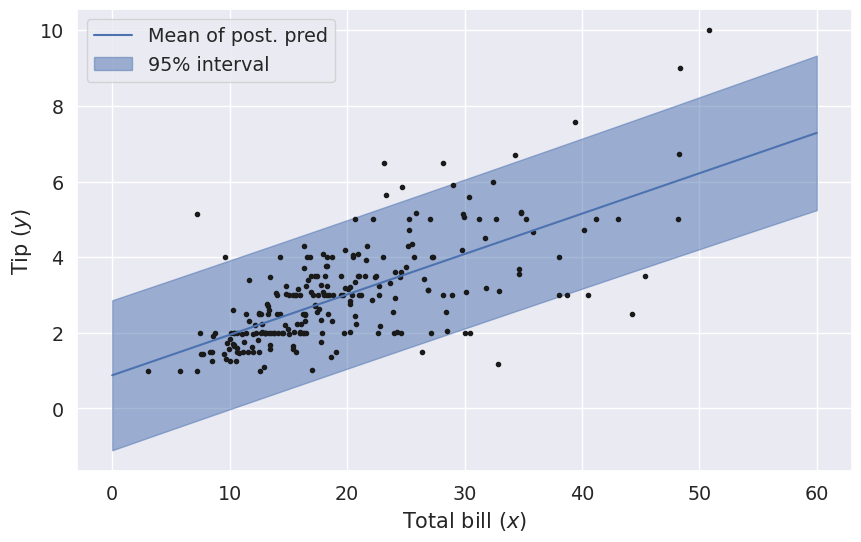

In [11]:
from ex9 import BayesianLinearRegression

# fit model
blr = BayesianLinearRegression(Phi, y_train, alpha=1./tau2, beta=1./sigma2)

# compute prediction for x* = 55
mu_star, var_star = blr.predict_y(Phi_star)

print(f'p(y*|y, x*=55) = N(y*|{mu_star[0]:.2}, {var_star[0]:.2f}) [Using code from week 3]')

# let's also plot the predictions
x_pred = jnp.linspace(0, 60, 101)
Phi_pred = design_matrix(x_pred)

# compute prediction and intervals for plotting
mu_pred, var_pred = blr.predict_y(Phi_pred)
lower, upper = mu_pred - 1.96*jnp.sqrt(var_pred), mu_pred + 1.96*jnp.sqrt(var_pred)

# plot
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
plot_data(ax)
ax.plot(x_pred, mu_pred, label='Mean of post. pred')
ax.fill_between(x_pred, lower, upper, color='b', alpha=0.5, label='95% interval')
ax.legend();

**End of solution**

The regression model in eq. (A) is **homoscedastic**, i.e. it assumes that noise variance is constant wrt. the input $x$. However, inspecting the data suggests that the noise variance grows with the size of the total bill $x$. Let's extend to model to be able to capture this.

First, let $\sigma_n^2 \equiv \sigma^2(x_n) > 0$ denote the **heteroscedastic** noise variance for the $n$'th data point such that
$$\sigma^2(x_n) = \text{softplus}(v_0 + v_1 x_n),$$
where the $\text{softplus}: \mathbb{R} \rightarrow \mathbb{R}_+$ function is given by $\text{softplus}(x) = \log(1+ e^x)$ and $\mathbf{v} = \begin{bmatrix} v_0 & v_1 \end{bmatrix}^T \in \mathbb{R}^2$ is a parameter vector. Since we are now equipped with HMC, we do not have to worry about conjugacy anymore - we can simply construct the model as we like and then use HMC for inference.

The new model is then given by
$$
\begin{align*}
y_n | x_n, \mathbf{w}, \mathbf{v} &\sim \mathcal{N}(y_n|f(x_n), \sigma^2(x_n)), \tag{B}\\
\mathbf{w} &\sim \mathcal{N}(0, \tau^2 \mathbf{I}),\\
\mathbf{v} &\sim \mathcal{N}(0, \tau^2 \mathbf{I}),
\end{align*}
$$
where the joint distribution is given by
$$
\begin{align*}
p(\mathbf{y}, \mathbf{w}, \mathbf{v}) &= p(\mathbf{w})p(\mathbf{v})p(\mathbf{y}| \mathbf{w}, \mathbf{v})\\
&=  \mathcal{N}(\mathbf{w}|0, \tau^2 \mathbf{I}) \mathcal{N}(\mathbf{v}|0, \tau^2 \mathbf{I})\prod_{n=1}^N \mathcal{N}(y_n|f(x_n), \sigma^2(x_n))
\end{align*}$$
We will use $\boldsymbol{\theta} = \left[\mathbf{w}, \mathbf{v}\right] \in \mathbb{R}^4$ to the denote all the parameters of the model. Moreover, we will assume $\tau^2 = 3$ (but we could also have imposed a hyperprior on $\tau$.)

To make it easier to validate our results and implementation, let's try to summarize about our expectations before fitting the model.

**Task 4.3**: Inspect the data again and think about what range of values you would expect for $\boldsymbol{\theta}$ in order for the model to fit the data. [**Discussion question**]

*Hints*:
- *What sign and magnitude do you expect (roughly) for each parameter?*

**Task:** Complete implementation of the function `predict` below.


In [12]:

softplus = lambda x: jnp.log(1 + jnp.exp(x))


def predict(x, theta):
    """ Computes and returns f(x) and g(x) for input x and parameters theta = [w0, w1, v0, v1]

        Arguments:
        x           -- input points, array of shape (N, 1)
        theta       -- parameter vector, array of shape (1, 4)

        Returns 
        f           -- the function f evalauted at input points x, array of shape (N, 1)
        sigma2      -- the function sigma2 evalauted at input points x, array of shape (N, 1)

    """
    # unpack parameters
    w0, w1, v0, v1 = theta[0,0], theta[0,1], theta[0,2], theta[0,3]
    f = w0 + w1*x 
    sigma2 = softplus(v0 + v1*x) 

    return f, sigma2

# sanity check
test_theta = jnp.array([[3., 1, jnp.log(jnp.e-1)-2, 1.]])
assert predict(jnp.array([[2.]]), test_theta)[0].item() == 5.0, f"The value of the first output for the predict function was expected to be 5.0 for the given input, but the actual output was {predict(jnp.array([[2.]]), test_theta)[0].item()}"
assert predict(jnp.array([[2.]]), test_theta)[1].item() == 1.0, f"The value of the second output for the predict function was expected to be 1.0 for the given input, but the actual output was {predict(jnp.array([[2.]]), test_theta)[1].item()}"
assert len(predict(jnp.ones(5), test_theta)[0]) == 5, f"For the given input, the predict function was expect to return a tuple of arrays of length 5, but the lengths appear to be wrong. Check your code."

**Task 4.4**: Complete the implementation of the function `log_joint`below.

*Hints*:
- *Use the function `predict` from the previous task.*

In [13]:
log_npdf = lambda x, m, v: -0.5*jnp.log(2*jnp.pi*v) - 0.5*(x-m)**2/v

def log_joint(theta):
    
    # predict
    f, sigma2 = predict(x_train, theta)
    

    # compute log_prior, log_likelihood and log joint
    log_prior = log_npdf(theta, 0, 3.).sum()                    # scalar 
    log_likelihood = jnp.sum(log_npdf(y_train, f, sigma2), axis=0)    # scalar 

    # return 
    return log_likelihood + log_prior

assert jnp.allclose(log_joint(jnp.zeros((1, 4))), -2103.22115194), "Output of log_joint seems to be wrong. Please check your code."
assert jnp.allclose(log_joint(jnp.ones((1, 4))), -2453.86113701), "Output of log_joint seems to be wrong. Please check your code."
print('Everything seems to be ok.')

Everything seems to be ok.


If the previous two cells have been implemented correctly, the cell below will run HMC with the following configuration:

- Number of chains: 2
- 500 iterations
- Number of leapfrog steps: $L = 50$
- Step-size $\eta = 5\cdot 10^{-3}$

We run multiple chains to be able to assess convergence using the $\hat{R}$-statistic.

In [14]:
# configuration
num_iterations = 2000 # solution: num_iterations = 500 
num_leapfrog_steps = 50
step_size = 5e-3
initial_thetas = [jnp.array([[0, 0, 1., 1.]]), jnp.array([[-1., -1., 5., 2.]])]

# run sampler for each initial theta
chains = []
for i, initial_theta in enumerate(initial_thetas):
    print(f'Running chain {i+1}')
    thetas = HMC(log_joint, num_iterations, initial_theta, num_leapfrog_steps, step_size, seed=i)
    chains.append(thetas)
chains = jnp.stack(chains) # shape: num_chains, num_samples, num_params

Running chain 1
Itt   200/2000 ( 10.00%), accept_rate=0.710, time=1.43s
Itt   400/2000 ( 20.00%), accept_rate=0.745, time=2.45s
Itt   600/2000 ( 30.00%), accept_rate=0.752, time=3.48s
Itt   800/2000 ( 40.00%), accept_rate=0.772, time=4.61s
Itt  1000/2000 ( 50.00%), accept_rate=0.780, time=5.67s
Itt  1200/2000 ( 60.00%), accept_rate=0.782, time=6.71s
Itt  1400/2000 ( 70.00%), accept_rate=0.785, time=7.71s
Itt  1600/2000 ( 80.00%), accept_rate=0.785, time=8.66s
Itt  1800/2000 ( 90.00%), accept_rate=0.786, time=9.61s
Itt  2000/2000 (100.00%), accept_rate=0.785, time=10.53s
HMC done in 10.534s with an avg. accept rate=0.785


Running chain 2
Itt   200/2000 ( 10.00%), accept_rate=0.695, time=1.29s
Itt   400/2000 ( 20.00%), accept_rate=0.745, time=2.43s
Itt   600/2000 ( 30.00%), accept_rate=0.752, time=3.65s
Itt   800/2000 ( 40.00%), accept_rate=0.767, time=4.79s
Itt  1000/2000 ( 50.00%), accept_rate=0.781, time=6.00s
Itt  1200/2000 ( 60.00%), accept_rate=0.789, time=7.12s
Itt  1400/2000 ( 7

Before we make predictions, let's plot the traces and histograms below and assess convergence.

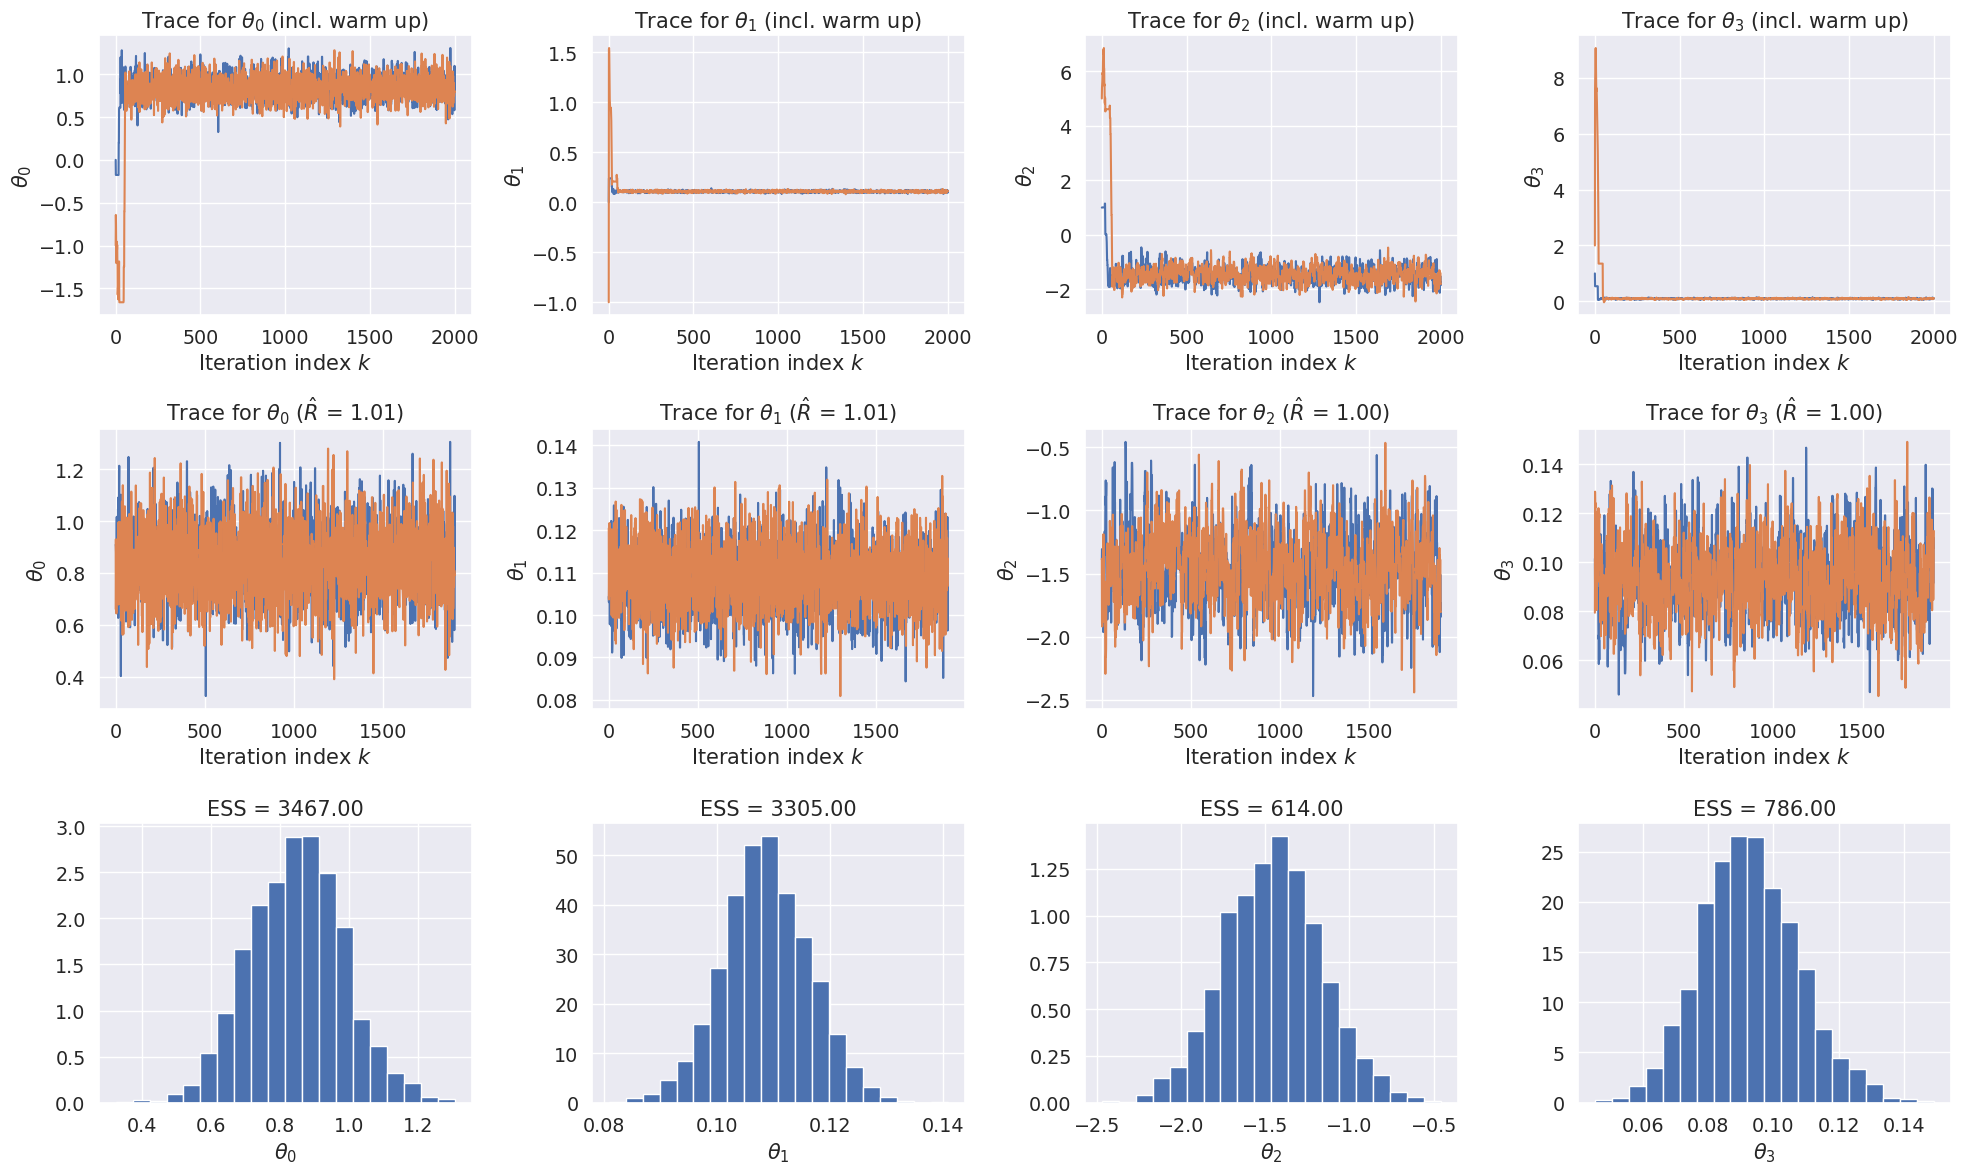

In [15]:
# number of warm-up samples
warm_up = 100

# compute Rhat and ESS-statistics
Rhat = compute_Rhat(chains[:, warm_up:, :])
ESS = compute_effective_sample_size(chains[:, warm_up:, :])

# plot
fig, ax = plt.subplots(3, 4, figsize=(20, 12))
for i in range(4):
    ax[0, i].plot(chains[:, :, i].T)
    ax[1, i].plot(chains[:, warm_up:, i].T)
    ax[0, i].set(xlabel='Iteration index $k$', ylabel=f'$\\theta_{i}$', title=f'Trace for $\\theta_{i}$ (incl. warm up)')

    ax[1, i].set(xlabel='Iteration index $k$', ylabel=f'$\\theta_{i}$', title=f'Trace for $\\theta_{i}$ ($\\hat{{R}}$ = {Rhat[i]:.2f})')
    ax[2, i].hist(chains[:, warm_up:,  i].flatten(), 20, density=True)
    ax[2, i].set(xlabel=f'$\\theta_{i}$')
    ax[2, i].set(title=f'ESS = {ESS[i]:.2f}')
fig.tight_layout()

**Task 4.5**: Inspect the plots above. Explain what you see in the trace plots. Do the chains appear to have mixed? Do the $\hat{R}$ values suggest convergence?  Change the step-size to $\eta = 10^{-4}$ and explain what happens. [**Discussion question**]

**Task 4.6**: Compute the posterior mean, standard deviation, and a 95\% interval for each of the 4 parameters.

*Hints:*
- *Remember to merge the chains before computing the posterior statistics*

**Solution**

In [16]:
merged_chains = chains[:, warm_up:, :].reshape(-1, 4)

for i in range(4):
    theta_i = merged_chains[:, i]
    post_mean = jnp.mean(theta_i)
    post_stddev = jnp.std(theta_i)

    lower, upper = jnp.percentile(theta_i, jnp.array([2.5, 97.5]))
    print(f'theta{i}: posterior mean={post_mean:+.2f}, \tstddev={post_stddev:.2f} \t95%-interval: [{lower:+.2f}, {upper:+.2f}]') 

theta0: posterior mean=+0.85, 	stddev=0.14 	95%-interval: [+0.59, +1.13]
theta1: posterior mean=+0.11, 	stddev=0.01 	95%-interval: [+0.09, +0.12]
theta2: posterior mean=-1.45, 	stddev=0.29 	95%-interval: [-2.02, -0.86]
theta3: posterior mean=+0.09, 	stddev=0.02 	95%-interval: [+0.06, +0.13]


**End of solution**

Next, let's compute and visualize the posterior predictive distribution.

**Task 4.7**: Compute and plot the (approximate) posterior predictive distribution $p(y^*|\mathbf{y}, x^*)$ and the posterior distributions for $f(x^*)$ and $\sigma^2(x^*)$ for $x^* \in \left[0, 60\right]$. 

*Hints*:

- *$f(x^*)$ and $\sigma^2(x^*)$ can be computed sample by sample*

- *What is the distribution of $y^*|(x^*), \sigma^2(x^*)$?*

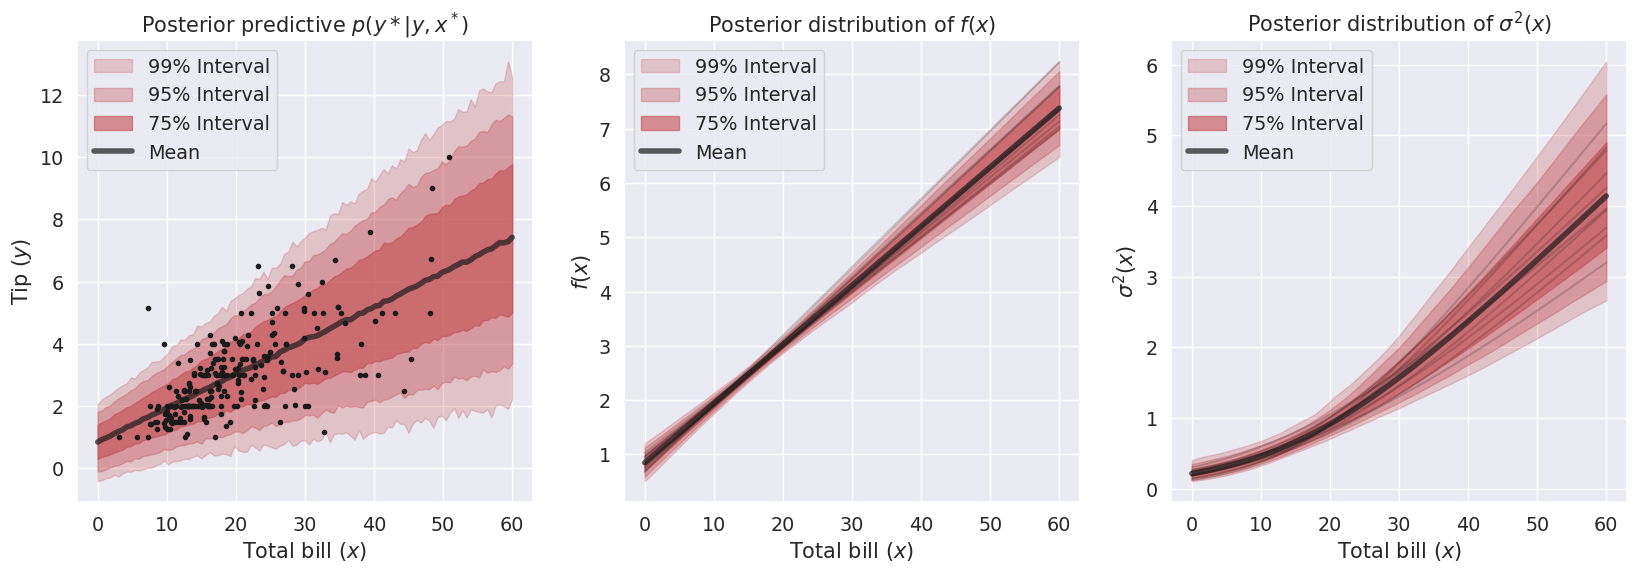

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(20, 6))
plot_data(ax[0])
ax[0].set(title='Posterior predictive $p(y*|y, x^*)$')
ax[1].set(xlabel='Total bill ($x$)', ylabel='$f(x)$', title='Posterior distribution of $f(x)$')
ax[2].set(xlabel='Total bill ($x$)', ylabel='$\\sigma^2(x)$', title='Posterior distribution of $\\sigma^2(x)$')

##############################################################
# Your solution goes here
##############################################################

f_samples, sigma2_samples, y_samples  = [], [], []
key = random.PRNGKey(1)
for theta_i in merged_chains:
    key, subkey = random.split(key)

    # make prediction for the i'th sample
    f_sample, sigma2_sample = predict(x_pred, theta_i[None, :])

    # sample y^*|f(x^*), g(x^*)
    y_sample = f_sample + jnp.sqrt(sigma2_sample)*random.normal(subkey, shape=f_sample.shape)

    # store results
    y_samples.append(y_sample)
    f_samples.append(f_sample)
    sigma2_samples.append(sigma2_sample)

# convert to jax array
y_samples = jnp.array(y_samples)
f_samples = jnp.array(f_samples)
sigma2_samples = jnp.array(sigma2_samples)

# plot using code from week 8
plot_predictions(ax[0], x_pred, y_samples, num_samples=0, legend=True, sample_alpha=.2)
plot_predictions(ax[1], x_pred, f_samples, num_samples=10, legend=True, sample_alpha=.2)
plot_predictions(ax[2], x_pred, sigma2_samples, num_samples=10, legend=True, sample_alpha=.2)

##############################################################
# End of solution
##############################################################

# Part 5:  HMC for a small Bayesian neural network

While HMC is considered the gold standard for Bayesian inference, it is hard to scale to modern large-scale neural networks and datasets. But let's run it for a small neural network.

Note that because of the severe multimodality of the posterior distribution for neural networks, the sampler will often get stuck in one or more modes and hence, the convergence diagnostics across multiple chains are generally not informative.

Let's build a small two-layer MLP for the tip data for the sake of curiosity:

In [18]:
def mlp(x, params):
    """ Implements forward pass for a 3-layer MLP.
    
    Arguments:
    x       -- Input data, JaX array of shape (N, 1)
    params  -- Dictionary containing parameters for each layer 'w1', 'b1', 'w2', 'b2', 'w3', 'b3'

    Return  
    f       -- Outputs, JaX array of shape (N, 2)
    
    """
    # Layer 1: Hidden Layer with tanh activation
    h = jnp.dot(x, params['w1']) + params['b1']
    h = jnp.tanh(h)

    # Layer 2: Hidden Layer with tanh activation
    h = jnp.dot(h, params['w2']) + params['b2']
    h = jnp.tanh(h)
    
    # Layer 3: Output Layer 
    f = jnp.dot(h, params['w3']) + params['b3']
    
    return f

# dimensions
input_dim = 1
hidden_dim = 10
output_dim = 2

# let's create some random parameters
key = random.PRNGKey(0)

params = {
    'w1': random.normal(key, (input_dim, hidden_dim)),
    'b1': jnp.zeros(hidden_dim),
    'w2': random.normal(key, (hidden_dim, hidden_dim)),
    'b2': jnp.zeros(hidden_dim),
    'w3': random.normal(key, (hidden_dim, output_dim)),
    'b3': jnp.zeros(output_dim),
}

# let's test it
output = mlp(x_train, params)
output.shape

(244, 2)

In the above cell, we implemented the network from scratch, but there are also JaX packages for implementing models in torch-style, see e.g. Stax, Flax or equinox.

The parameters of the network is currently represented using a dictionary of arrays. To make the `mlp`-function compatible with our HMC sampler, we will convert these parameters to a flat array. (In fact, JaX has rich such data structures (pytrees), so we could easily have extended our HMC implemented to support the dictionaries, but that's for a different day and a different course).

For now, we will use the `ravel_pytree` function which returns a flattened parameter as well as a function to unflatten the parameters again. 

In [19]:
params_flat, unflatten = ravel_pytree(params)
D = len(params_flat)
print(f'Num. params: {D}')

Num. params: 152


We can now implement a new predict function and run HMC again.

In [20]:
@jit
def predict(x, theta):
    params = unflatten(theta.T)
    output = mlp(x, params)
    return softplus(output[:, 0, None]), softplus(output[:, 1, None]) # note we have used softplus activation function for both outputs

thetas = HMC(log_joint, num_iterations=25000, theta0=params_flat[None, :], step_size=1e-3)

Itt  2500/25000 ( 10.00%), accept_rate=0.979, time=5.28s
Itt  5000/25000 ( 20.00%), accept_rate=0.963, time=11.06s
Itt  7500/25000 ( 30.00%), accept_rate=0.963, time=17.27s
Itt 10000/25000 ( 40.00%), accept_rate=0.968, time=22.98s
Itt 12500/25000 ( 50.00%), accept_rate=0.970, time=28.77s
Itt 15000/25000 ( 60.00%), accept_rate=0.972, time=34.56s
Itt 17500/25000 ( 70.00%), accept_rate=0.973, time=40.47s
Itt 20000/25000 ( 80.00%), accept_rate=0.974, time=46.24s
Itt 22500/25000 ( 90.00%), accept_rate=0.976, time=52.00s
Itt 25000/25000 (100.00%), accept_rate=0.975, time=57.75s
HMC done in 57.747s with an avg. accept rate=0.975




Note that we have overwritten the `predict`-function, which changes the behavior of the `log_joint` function, so make sure to rerun the code if you go back up to the linear model.

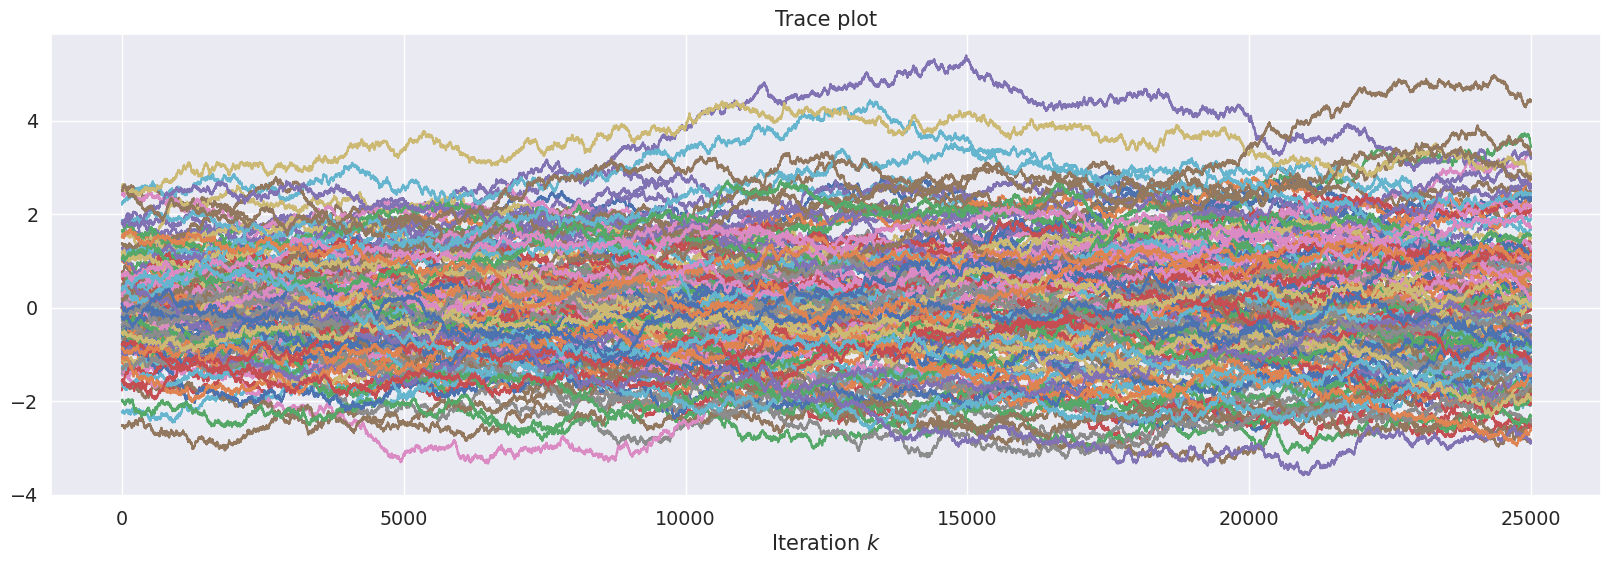

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(20, 6))
ax.plot(thetas);
ax.set(xlabel='Iteration $k$', title='Trace plot');

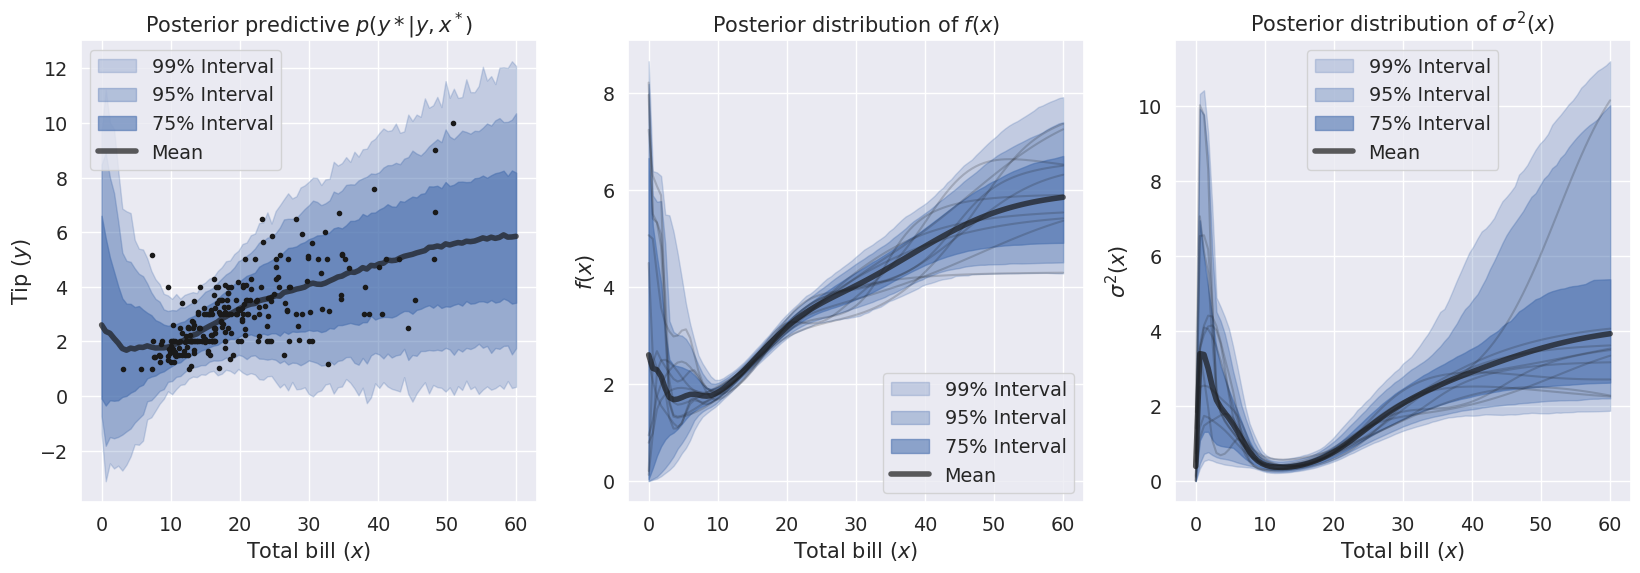

In [22]:
warm_up = int(0.5*num_iterations) # use 50% for warm-up
thin = 10                         # skip every 10th samples to speed up computations and decorrelate samples

fig, ax = plt.subplots(1, 3, figsize=(20, 6))
plot_data(ax[0])
ax[0].set(title='Posterior predictive $p(y*|y, x^*)$')
ax[1].set(xlabel='Total bill ($x$)', ylabel='$f(x)$', title='Posterior distribution of $f(x)$')
ax[2].set(xlabel='Total bill ($x$)', ylabel='$\\sigma^2(x)$', title='Posterior distribution of $\\sigma^2(x)$')

f_samples, sigma2_samples, y_samples  = [], [], []
key = random.PRNGKey(1)
for theta_i in thetas[warm_up::thin]:
    key, subkey = random.split(key)

    # make prediction for the i'th sample
    f_sample, sigma2_sample = predict(x_pred[:, None], theta_i)

    # sample y^*|f(x^*), g(x^*)
    y_sample = f_sample + jnp.sqrt(sigma2_sample)*random.normal(subkey, shape=f_sample.shape)

    # store results
    y_samples.append(y_sample)
    f_samples.append(f_sample)
    sigma2_samples.append(sigma2_sample)

# convert to jax array
y_samples = jnp.stack(y_samples)
f_samples = jnp.array(f_samples)
sigma2_samples = jnp.array(sigma2_samples)

# plot using code from week 8
plot_predictions(ax[0], x_pred, y_samples.squeeze(), num_samples=0, legend=True, sample_alpha=.2, color='b')
plot_predictions(ax[1], x_pred, f_samples.squeeze(), num_samples=10, legend=True, sample_alpha=.2, color='b')
plot_predictions(ax[2], x_pred, sigma2_samples.squeeze(), num_samples=10, legend=True, sample_alpha=.2, color='b')

**Task 5.1**: Compare the fit of the neural network to the linear model. How would you decide on the best model? [**Discussion question**]



**Task 5.2**: Suppose you want to test whether you get better predictive performance using a student's t likelihood rather than the Gaussian. What would you need to change in the implementation?

**Solution**

Both the linear model and the neural network are off the form
$$y = f(x) + \epsilon,$$
and changing the likelihood from Gaussian to student's t only changes the distribution of the noise, $\epsilon$. Thefore, the implementation of the `predict`-function does not need any changes, but we need to change the following:
1) the implementation of the likelihood in the `log_joint` function, where we need to switch the Gaussian likelihood with the student's t likelihood (and decide on the number of degrees of freedom)
2) the implementation of the posterior predictive. We would need to sample from a student's t distribution rather than from a Gaussian when computing `y_sample`

**End of solution**

**Task 5.3**: Suppose you implemented both likelihoods (Gaussian & student's t) for both models (linear model & neural network). How would you set up a formal model selection pipeline and assess the generalization error of the best model? What metrics would you focus on? [**Discussion question**]
 